In [ ]:
import torch 
import os, sys
import numpy as np
os.environ["T2struc_NAME"] = "T2struc-15B"
sys.path.append("../../")
from utils.design_utils import load_pinal

t2struc, text_tokenizer, structre_tokenizer, saprot, saprot_text_tokenizer, saprot_tokenizer = load_pinal()


/storage/yuanfajieLab/yuanfajie/miniconda3/envs/genesis/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[21:59:13] INFO     Loading Pinal...                                                             ]8;id=11001;file:///storage/yuanfajieLab/yuanfajie/fengyuan/Denovo-Pinal/utils/design_utils.py\design_utils.py]8;;\:]8;id=925174;file:///storage/yuanfajieLab/yuanfajie/fengyuan/Denovo-Pinal/utils/design_utils.py#89\89]8;;\

           INFO     T2strcu Model: T2struc-15B                                                   ]8;id=788369;file:///storage/yuanfajieLab/yuanfajie/fengyuan/Denovo-Pinal/utils/design_utils.py\design_utils.py]8;;\:]8;id=929193;file:///storage/yuanfajieLab/yuanfajie/fengyuan/Denovo-Pinal/utils/design_utils.py#72\72]8;;\

/storage/yuanfajieLab/yuanfajie/miniconda3/envs/genesis/lib/python3.8/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


[2026-06-16 22:02:12,762] [INFO] [real_accelerator.py:191:get_accelerator] Setting ds_accelerator to cuda (auto detect)


[22:02:15] INFO     Pinal loaded successfully.                                                   ]8;id=606473;file:///storage/yuanfajieLab/yuanfajie/fengyuan/Denovo-Pinal/utils/design_utils.py\design_utils.py]8;;\:]8;id=434484;file:///storage/yuanfajieLab/yuanfajie/fengyuan/Denovo-Pinal/utils/design_utils.py#94\94]8;;\

## Recalculate the NLL of pinalpetase36 and pinalpetase_old

In [ ]:
DEVICE="cuda"
@torch.no_grad()
def _CalNLL(desc, InputSeq, InputStruc, t2struc, text_tokenizer, structre_tokenizer, saprot, saprot_text_tokenizer, saprot_tokenizer):
    t2struc_batch = {}

    struc_encode = structre_tokenizer(
        InputStruc,
        return_tensors="pt",
        max_length=1024,
        truncation=True,
        padding="longest",
    )
    t2struc_batch["structure_token_ids"] = struc_encode.input_ids.to(DEVICE)
    t2struc_batch["structure_token_masks"] = struc_encode.attention_mask.to(DEVICE)
    desc_encodings = text_tokenizer(
        desc,
        return_tensors="pt",
        max_length=768,
        truncation=True,
        padding="longest",
    )
    t2struc_batch["text_ids"] = desc_encodings.input_ids.to(DEVICE)
    t2struc_batch["text_masks"] = desc_encodings.attention_mask.to(DEVICE)
    t2struc_batch["text_hidden_states"], t2struc_batch["text_attention_mask"] = t2struc.infer_text(t2struc_batch)
    struc_out = t2struc.infer(t2struc_batch, 
                        text_hidden_states=t2struc_batch["text_hidden_states"],
                        text_attention_mask=t2struc_batch["text_attention_mask"],)
    struct_nll_all = struc_out["outputs"]["loss"] * (len(InputSeq) + 1)
    struct_nll_per_token = struc_out["outputs"]["loss"]
    
    ### sequence
    saprot_input = []
    saprot_input.append("#" + "#".join([i for i in InputStruc if i.isalpha() or i == "#"]))
    inputs = saprot_tokenizer(saprot_input, return_tensors="pt", max_length=1024, truncation=True, padding="longest")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    ## saprot not mask
    saprot_input_nomask = []
    saprot_input_nomask.append("".join([f"{j}{i}" for j, i in zip(InputSeq, InputStruc) if i.isalpha() or i == "#"]))
    inputs_no_mask = saprot_tokenizer(saprot_input_nomask, return_tensors="pt", max_length=1024, truncation=True, padding="longest")
    inputs_no_mask = {k: v.to(DEVICE) for k, v in inputs_no_mask.items()}
    encodings = saprot_text_tokenizer(
        desc,
        padding="longest", # max_length,longest
        truncation=True,
        max_length=512,
        return_tensors="pt",
    )
    saprot_text_ids = encodings["input_ids"].to(DEVICE)
    saprot_text_masks= encodings["attention_mask"].to(DEVICE)
    SaProtInputDict= {
            "mask_prot_ids": inputs["input_ids"],
            "prot_masks": inputs["attention_mask"],
            'text_ids': saprot_text_ids,
            'text_masks': saprot_text_masks, 
            "prot_ids": inputs_no_mask["input_ids"]
        }
    seq_out = saprot(SaProtInputDict)
    seq_nll_all = seq_out["outputs"]["loss"] * (len(InputSeq) + 2)
    seq_nll_per_token =  seq_out["outputs"]["loss"]

    return {
        "struct_nll_all": struct_nll_all.cpu().item(), 
        "seq_nll_all": seq_nll_all.cpu().item(),
        "struct_nll_per_token": struct_nll_per_token.cpu().item(), 
        "seq_nll_per_token": seq_nll_per_token.cpu().item()}

In [ ]:
desc = "PET hydrolases are a class of enzymes capable of catalyzing the degradation of polyethylene terephthalate (PET), a widely used plastic found in bottles and packaging. This enzyme class includes cutinases, lipases, and esterases, which hydrolyze the ester bonds in PET through a conserved catalytic triad (Ser–His–Asp/Glu). PETase is a well-characterized PET hydrolase that specifically targets and breaks down PET polymers."

seq_dict1 = {"name": "pinalpetase36", "seq": "MAITTGAGPAPTAATLQASSGPYSVTSVSVSSTGASGFGGGTIYYPTASGSFGAVAISPGFTGSQSSIAWLARHLASHGFVVVAINTNSTLDSPQNRGNQLISALDYLTNSAPAAVTAKIDTGRLGVMGHSMGGGGTLIAATQRPDLKAAIPLTPWNLTTNFSGIKAPTLIIGAQNDTIAPVALHSRPFYNSLPSDVPKAYIEITGATHFTPTFPNPTISRYSVAWLKRYVDGDARYDSYLCPGPTPGTNPNISRYKTNNPP", "structure_token": "ddqplddddqddlvqlldlahqfdkdkdwfpcvlqdlfhtfikiagpdqdaaaeeeeeeaqldalllqvslqnrlrrngytytrthgpdshdalcsllssrvsvlvcqcppddpssnsrydnqqyayeyaasnlssqlnnqlvcvsyqegerelyhdpdlascsgqhqyeyehecaeppshcvnhvvsnqvnhdlphwykywyfapdysspssdddslcssvvnlssccgssvncssqvcvvvhddapphrgtndmdtsppd"}
seq_dict2 = {"name": "pinalpetase_old", "seq": "MKLLALLLLLAASAGAALLAAYAAPGPYSVTTETIPAPSSQPGFTSALLYRPVGSGPFPGVAISPGLGGSSASSYAWLGEHLASHGFVVIAVNTNSPLDTPQTRAQQLLAALDYLKSQPASYRVDTSRLGVLGHSMGGGGVLAAAAADPDLAAVVPLAPWTPSGAPPPLTFPVLMIAGDADTITPPSAVRAFYNSLPSGVDKAYVELKGASHFDFYSDPLPRGYATAWFKRYLDGDTDAAALFEPNGELTTSPRVASYRNYSGPP", "structure_token": "dddddddddpddppqqvllvvlldaaqfdkdwdwaaddpvqpqfgikikiatpdqpafaeeeeleaadqaanvqqvllcnslrsvrytymtthgphshdalqsllsrrvvrlvvlcpddcsnhhdnlhyeyeyaarnlsnrlnncqvpvshleyeyelydadpdqgderphayeyeyecqeppshlvnvvvrqvsydapykykyfywypdysscprvpnrvsslvslrsccrrvvdpvsclcqddprvqcpppggphidpidhpd"}

In [29]:
res = _CalNLL(desc, seq_dict1["seq"], seq_dict1["structure_token"], t2struc, text_tokenizer, structre_tokenizer, saprot, saprot_text_tokenizer, saprot_tokenizer)
nll_per_residue = res["struct_nll_per_token"] + res["seq_nll_per_token"]
ppl = np.exp(nll_per_residue)
nll_per_residue, ppl # should be (0.73046875, 2.0760535297197595)

(0.73046875, 2.0760535297197595)

In [30]:
res = _CalNLL(desc, seq_dict2["seq"], seq_dict2["structure_token"], t2struc, text_tokenizer, structre_tokenizer, saprot, saprot_text_tokenizer, saprot_tokenizer)
nll_per_residue = res["struct_nll_per_token"] + res["seq_nll_per_token"]
ppl = np.exp(nll_per_residue)
nll_per_residue, ppl # should be (1.87890625, 6.546340884762466)

(1.87890625, 6.546340884762466)

## plot the distribution of nll of all designed petase.

In [1]:
## Directly load the NLL values of the designed proteins to avoid recalculation.
## Note that the loaded NLL values may not be exactly identical to the recalculated values,
## because T2Struct applies logits processors/warpers during generation.
## In practice, this difference is very minor and can be ignored.

In [ ]:
from pathlib import Path
import numpy as np 

seq2ppl = {}
rank_files = Path("../outputs/petase/rank_files/").glob("res_rank*")
for rank_file in rank_files:
    with open(rank_file, 'r') as f:
        first_line = f.readline()
        for line in f:
            struct, p_1, seq, p_2 = line.strip().split("\t")
            seq_len = len(seq)
            nll_1 = - float(p_1) / (seq_len + 1)
            nll_2 = - float(p_2) / (seq_len + 2)
            seq2ppl[seq] = np.exp(nll_1 + nll_2)
len(seq2ppl)

50000

In [26]:
ppl1 = 2.0760535297197595
ppl2 = 6.546340884762466
ppl_rank_fn = lambda x: sum(1 if x > i else 0 for i in seq2ppl.values()) / len(seq2ppl.values())

ppl_rank_fn(ppl1), ppl_rank_fn(ppl2)

(0.01218, 0.15086)

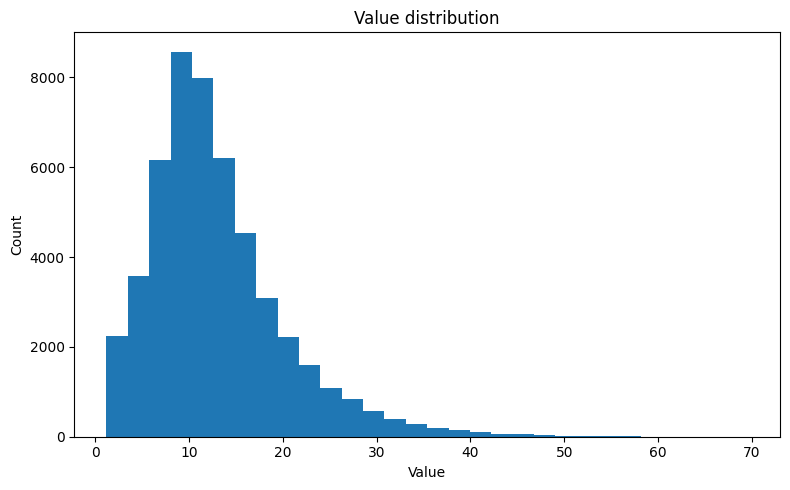

In [ ]:
import matplotlib.pyplot as plt

values = seq2ppl.values()

plt.figure(figsize=(8, 5))
plt.hist(values, bins=30)

plt.xlabel("PPL")
plt.ylabel("Count")
plt.title("PPL distribution")

plt.tight_layout()
plt.show()